# Butterworth Low-Pass Filter Design Using Python and LTspice

## Project Requirements

Design a third-order Butterworth low-pass filter that satisfies specified passband and stopband attenuation requirements. The filter shall be synthesized using classical Butterworth approximation techniques, analyzed using Python, and implemented as an active Sallen-Key filter in LTspice.

### Design Specifications

| Parameter                    | Value                             |
| ---------------------------- | --------------------------------- |
| Filter Type                  | Low-Pass                          |
| Approximation                | Butterworth                       |
| Passband Attenuation $(A_p)$ | 3 dB                              |
| Stopband Attenuation $(A_s)$ | 40 dB                             |
| Passband Frequency $(f_p)$   | 1 kHz                             |
| Stopband Frequency $(f_s)$   | 5 kHz                             |
| Implementation Method        | Sallen-Key Active Filter          |
| Design Tool                  | Python (SciPy, NumPy, Matplotlib) |
| Verification Tool            | LTspice                           |

### Objectives

1. Determine the minimum Butterworth filter order that satisfies the design requirements.
2. Calculate the Butterworth cutoff frequency.
3. Generate the analog transfer function using Python.
4. Analyze poles, frequency response, and attenuation characteristics.
5. Factor the transfer function into realizable first-order and second-order sections.
6. Design a Sallen-Key active filter implementation.
7. Calculate practical resistor and capacitor values.
8. Simulate the circuit in LTspice.
9. Compare theoretical and simulated frequency responses.
10. Verify that the filter meets the required attenuation specifications.

### Expected Deliverables

* Filter order ((n))
* Cutoff frequency ((f_c))
* Transfer function (H(s))
* Pole locations
* Bode magnitude and phase plots
* Component value calculations
* LTspice schematic
* LTspice simulation results
* Comparison between theoretical and simulated responses

### Engineering Applications

This design workflow is commonly used in:

* Sensor signal conditioning
* Anti-aliasing filters for ADC systems
* Audio signal processing
* Instrumentation systems
* Communication receivers
* Embedded and IoT measurement systems

### Success Criteria

The final design shall:

* Exhibit a maximally flat Butterworth response.
* Achieve approximately −3 dB at the cutoff frequency.
* Provide at least 40 dB attenuation at the stopband frequency.
* Match theoretical predictions within acceptable component tolerances.
* Produce comparable results in Python analysis and LTspice simulation.


In [2]:
import numpy as np
import scipy as scp
import seaborn as sns
from scipy import signal
import numpy as np
from control import matlab as mt
from warnings import filterwarnings
import sympy as sp
import matplotlib.pyplot as plt

filterwarnings("ignore")

In [4]:
from sympy.abc import S

In [5]:
#Requirements

Ap=3 #dB
As=40 # dB
Wp=2e3*np.pi #rad/s
Ws=10e3*np.pi #rad/s

In [6]:
#Determine filter order and cut of frequency
N,Wn=signal.buttord(Wp,Ws,Ap,As,analog=True)

In [7]:
print(f"Filter Order: {N}")
print(f"Cut-off Frequency: {Wn}")

Filter Order: 3
Cut-off Frequency: 6288.160357707619


In [8]:
#obtain the coefficients of numerator and denominator
b,a=signal.butter(N,Wn,analog=True)

In [9]:
b

array([2.48639901e+11])

In [10]:
a

array([1.00000000e+00, 1.25763207e+04, 7.90819214e+07, 2.48639901e+11])

In [11]:
sys=mt.tf(b,a)

In [12]:
sys

TransferFunction(
array([2.48639901e+11]),
array([1.00000000e+00, 1.25763207e+04, 7.90819214e+07, 2.48639901e+11]),
outputs=1, inputs=1)

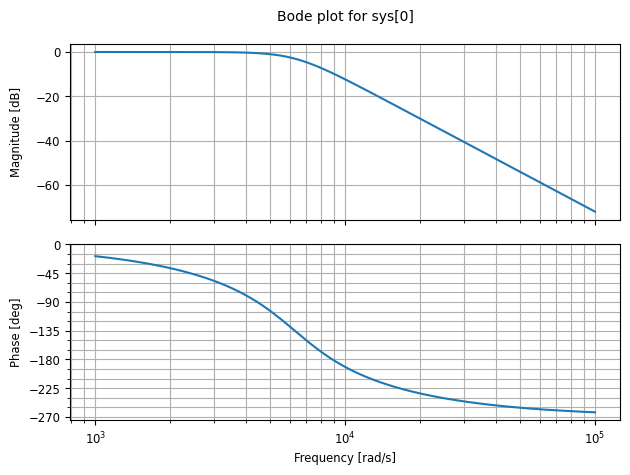

In [13]:
mag,phase,omega=mt.bode(sys)
plt.show()

# Determine the values of the components- Resistor and Capacitor and scaling.,

Using Sallen-Key Configuration for implementing the circuit

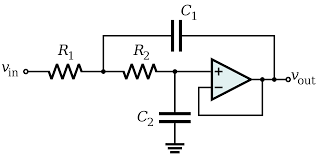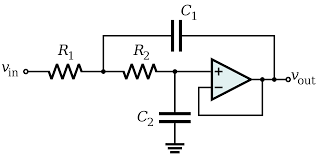


$R_1=R_2$   and $C_1=C_2$

$C1=C2=10nF$

$Q=\frac{1}{3-K}$

First order

$W_c=\frac{1}{RC}$

In [14]:
C1=10e-9 #nF

In [15]:
#Normalise the transfer function.
den=(S**3+1.258e4*S**2+7.908e7*S+2.486e11)
den

S**3 + 12580.0*S**2 + 79080000.0*S + 248600000000.0

In [16]:
sol=sp.solve(den)
sol

[-6291.13829745594,
 -3144.43085127203 - 5443.20272608781*I,
 -3144.43085127203 + 5443.20272608781*I]

In [17]:
#Expansions for the second order
exp=(S-sol[1])*(S-sol[2])
exp=sp.expand(exp)

In [18]:
#Second order transfer function
H2=sp.cbrt(2.486e11)**2/(exp)
H2

39536730.2421258/(S**2 + 6288.86170254406*S + 39515901.2957211)

In [19]:
#First Order transfer function
H1=sp.cbrt(2.486e11)/(S-sol[0])
H1

6287.82396717066/(S + 6291.13829745594)

In [20]:
#Resistor for first order section
R1=1/((sp.cbrt(2.486e11)*C1))
print(f"First Order Resistor Value={R1}")

First Order Resistor Value=15903.7531142904


In [22]:
#Second Gain value
#Q at wc=1
K=3-1
#Determine value of Rf and Rg for the gain (non-inverting)
Rf=Rg=10e3 # 10kOhm